#Adversarial Robustness of Neural Networks: FGSM Attacks, Adversarial Training, and Cross-Architecture Transferability on CIFAR-10


#Set Up and Configuration

In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [2]:
%%capture
!pip install torchattacks

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random
import numpy as np
import time
import os
import matplotlib.ticker as mticker
import subprocess
import torchattacks

In [4]:
config_yaml = """
dataset:
  mean: [0.4914, 0.4822, 0.4465]
  std:  [0.2023, 0.1994, 0.2010]
  root: /content/drive/MyDrive/cifar_project/datasets
  num_classes: 10
  classes: [plane, car, bird, cat, deer, dog, frog, horse, ship, truck]

training:
  batch_size: 64
  test_batch_size: 128
  epochs: 30
  lr: 0.1
  momentum: 0.9
  weight_decay: 0.0005
  seed: 42

model:
  name: resnet18
"""

with open('/content/drive/MyDrive/cifar_project/config.yaml', 'w') as f:
    f.write(config_yaml)
print("Config saved!")

Config saved!


In [5]:
import yaml

with open('/content/drive/MyDrive/cifar_project/config.yaml') as f:
    cfg = yaml.safe_load(f)

MEAN            = cfg['dataset']['mean']
STD             = cfg['dataset']['std']
CLASSES         = cfg['dataset']['classes']
ROOT            = cfg['dataset']['root']
NUM_CLASSES     = cfg['dataset']['num_classes']
LR              = cfg['training']['lr']
EPOCHS          = cfg['training']['epochs']
BATCH_SIZE      = cfg['training']['batch_size']
TEST_BATCH_SIZE = cfg['training']['test_batch_size']
MOMENTUM        = cfg['training']['momentum']
WEIGHT_DECAY    = cfg['training']['weight_decay']
SEED            = cfg['training']['seed']
EPSILONS       = [0, 2/255, 4/255, 8/255, 16/255, 32/255]
EPSILON_LABELS = ['0', '2/255', '4/255', '8/255', '16/255', '32/255']

In [6]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Seed set to {SEED}")

Seed set to 42


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None, num_classes=NUM_CLASSES)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model = model.to(device)

print(f"Using: {device}")

Using: cuda


In [8]:
# Train transform: WITH augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Test transform: NO augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [9]:
trainset = torchvision.datasets.CIFAR10(
    root=ROOT,
    train=True, download=True, transform=train_transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

In [10]:
# Load CIFAR-10 test dataset and create DataLoader for evaluation
testset = torchvision.datasets.CIFAR10(
    root=ROOT,
    train=False,       # Use test split
    download=True,     # Download if not already present
    transform=test_transform  # Apply test-time transforms (e.g. normalize)
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,     # No shuffling needed for evaluation
    num_workers=2      # Parallel workers for faster data loading
)

In [11]:
# Reload all models from checkpoints
USE_CHECKPOINTS = True

CKPT = '/content/drive/MyDrive/cifar_project/checkpoints'

# Model A: Standard ResNet-18
model = models.resnet18(weights=None, num_classes=10)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model = model.to(device)
ckpt_a = torch.load(f'{CKPT}/baseline_resnet18.pt')
model.load_state_dict(ckpt_a['model_state_dict'])
model.eval()
print(f"Model A loaded: {ckpt_a['test_accuracy']:.2f}%")

# Model B: MobileNetV2
model_b = models.mobilenet_v2(weights=None, num_classes=10)
model_b.classifier[1] = nn.Linear(model_b.last_channel, 10)
model_b = model_b.to(device)
ckpt_b = torch.load(f'{CKPT}/model_b_mobilenetv2.pt')
model_b.load_state_dict(ckpt_b['model_state_dict'])
model_b.eval()
print(f"Model B loaded: {ckpt_b['test_acc']:.2f}%")

# Model AT: FGSM-AT ResNet-18
model_at = models.resnet18(weights=None, num_classes=10)
model_at.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_at.maxpool = nn.Identity()
model_at = model_at.to(device)
ckpt_at = torch.load(f'{CKPT}/fgsm_at_resnet18.pt')
model_at.load_state_dict(ckpt_at['model_state_dict'])
model_at.eval()
print(f"Model AT loaded: {ckpt_at['clean_accuracy']:.2f}%")

print("\nAll models loaded successfully")

Model A loaded: 93.81%
Model B loaded: 79.63%
Model AT loaded: 92.83%

All models loaded successfully


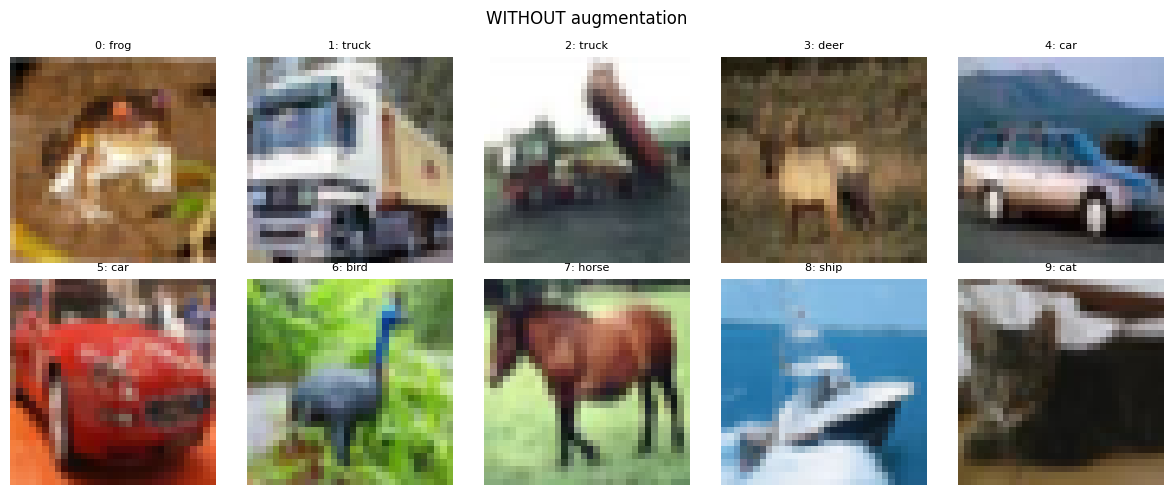

In [12]:
# WITHOUT augmentation (raw dataset)
trainset_raw = torchvision.datasets.CIFAR10(
    root=ROOT, train=True, download=False,
    transform=transforms.ToTensor()
)

# Define the index range of samples to visualize
start, end = 0, 10

# Create a 2x5 grid of subplots (one cell per image)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if start + i >= end:
        break
    image, label = trainset_raw[start + i]

    # Convert from (C,H,W) tensor to (H,W,C) numpy array for matplotlib;
    # clip ensures values stay in [0,1] after any floating point drift
    img = image.permute(1,2,0).numpy().clip(0,1)
    ax.imshow(img)
    ax.set_title(f"{start+i}: {CLASSES[label]}", fontsize=8)
    ax.axis('off')

plt.suptitle('WITHOUT augmentation', fontsize=12)
plt.tight_layout()
plt.show()

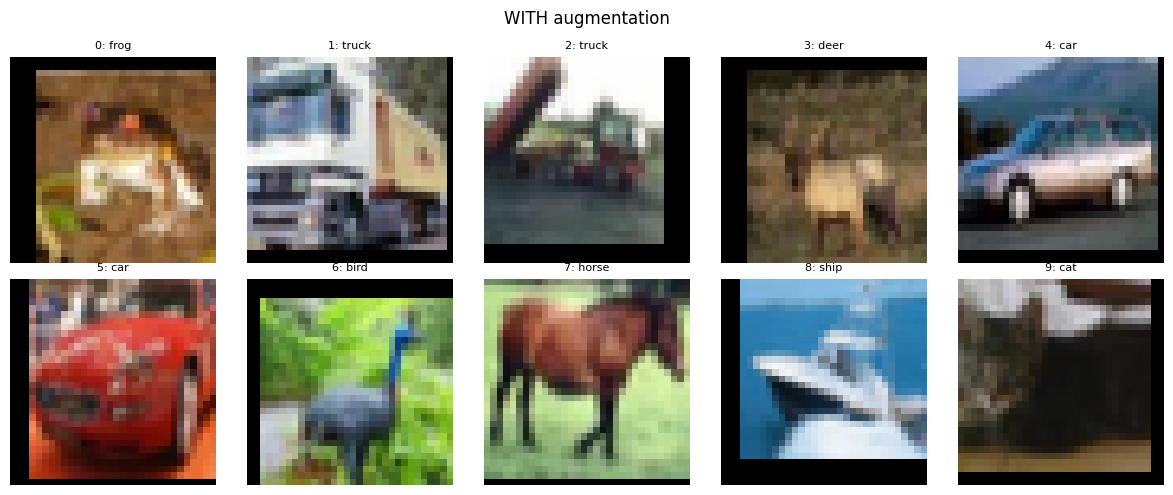

In [13]:
# WITH augmentation (same range)
start, end = 0, 10

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if start + i >= end:
        break
    image, label = trainset[start + i]
    mean = np.array(MEAN)
    std  = np.array(STD)

    # Convert tensor from (C,H,W) to (H,W,C) numpy array, then undo normalization:
    # original_pixel = normalized_value * std + mean
    img = image.permute(1,2,0).numpy()
    img = (img * std + mean).clip(0,1)
    ax.imshow(img)
    ax.set_title(f"{start+i}: {CLASSES[label]}", fontsize=8)
    ax.axis('off')

plt.suptitle('WITH augmentation', fontsize=12)
plt.tight_layout() # Prevent subplot overlap
plt.show()

In [14]:
# Loss, Optimizer, and LR Scheduler Setup

criterion = nn.CrossEntropyLoss()

# SGD with momentum and weight decay is a strong baseline for image classification
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

# Cosine Annealing smoothly decays the LR from its initial value down to ~0
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [15]:
images, labels = next(iter(trainloader))
images, labels = images.to(device), labels.to(device)

# Forward pass with zeros
zero_input = torch.zeros_like(images).to(device)
outputs_zero = model(zero_input)
loss_zero = criterion(outputs_zero, labels)

# Forward pass with real data
outputs_real = model(images.to(device))
loss_real = criterion(outputs_real, labels)

print(f"Real data loss: {loss_real.item():.3f}")
print(f"Zero input loss: {loss_zero.item():.3f}")

Real data loss: 0.024
Zero input loss: 4.963


In [16]:
if 'USE_CHECKPOINTS' in globals() and USE_CHECKPOINTS:
    print("Skipping overfit check — using checkpoint weights")
else:
    model.train()
    for step in range(100):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        if step % 10 == 0:
            print(f"Step {step}: loss = {loss.item():.4f}")
    print("Overfit check done\n")

Skipping overfit check — using checkpoint weights


In [17]:
# Reset model weights after overfit check (skip if loading from checkpoints)
if 'USE_CHECKPOINTS' in globals() and USE_CHECKPOINTS:
    print("Skipping reset — using checkpoint weights")
else:
    model = models.resnet18(weights=None, num_classes=NUM_CLASSES)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model = model.to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                                 momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

Skipping reset — using checkpoint weights


In [18]:
# Fixed test batch for prediction dynamics
# Same batch used every epoch to track how predictions evolve
fixed_images, fixed_labels = next(iter(testloader))
fixed_images = fixed_images.to(device)
fixed_labels = fixed_labels.to(device)

#Training loop for ResNet-18 (Model A)


In [19]:
import time

if 'USE_CHECKPOINTS' in globals() and USE_CHECKPOINTS:
    print("Skipping training — using checkpoint weights for Model A")
else:
    for epoch in range(EPOCHS):
        model.train()
        start = time.time()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

        scheduler.step()
        train_loss = running_loss / train_total
        train_acc = 100 * train_correct / train_total

        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                test_correct += (predicted == labels).sum().item()
                test_total += labels.size(0)

        test_acc = 100 * test_correct / test_total

        with torch.no_grad():
            fixed_outputs = model(fixed_images)
            _, fixed_predicted = fixed_outputs.max(1)
            fixed_acc = fixed_predicted.eq(fixed_labels).float().mean()

        elapsed = time.time() - start
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Acc: {test_acc:.2f}% | "
              f"Fixed Batch Acc: {fixed_acc:.3f} | "
              f"Time: {elapsed:.1f}s")

    print("\nTraining complete!")

Skipping training — using checkpoint weights for Model A


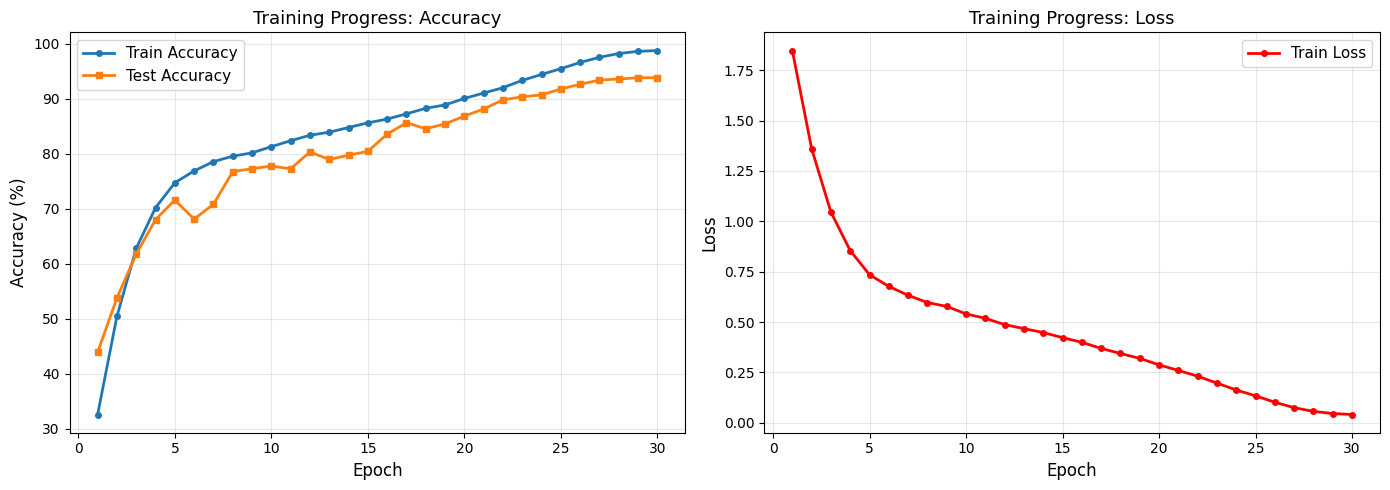

Final train acc: 98.75%
Final test acc:  93.81%
Gap: 4.94%


In [20]:
# Display training curves (all 30 epochs)
epochs_range = list(range(1, 31))

train_accs = [32.60, 50.45, 62.80, 70.18, 74.72, 76.87, 78.56, 79.55,
              80.15, 81.28, 82.36, 83.35, 83.91, 84.76, 85.61, 86.29,
              87.25, 88.25, 88.86, 90.04, 91.02, 91.99, 93.33, 94.40,
              95.45, 96.58, 97.52, 98.21, 98.60, 98.75]

test_accs = [43.89, 53.80, 61.74, 68.03, 71.58, 68.12, 70.81, 76.73,
             77.28, 77.76, 77.26, 80.32, 78.96, 79.72, 80.43, 83.55,
             85.63, 84.53, 85.42, 86.83, 88.13, 89.78, 90.34, 90.69,
             91.76, 92.62, 93.38, 93.58, 93.80, 93.81]

train_losses = [1.8477, 1.3608, 1.0459, 0.8546, 0.7352, 0.6770, 0.6329, 0.5971,
                0.5776, 0.5408, 0.5185, 0.4876, 0.4676, 0.4480, 0.4229, 0.3996,
                0.3693, 0.3442, 0.3199, 0.2878, 0.2601, 0.2316, 0.1971, 0.1631,
                0.1339, 0.1022, 0.0751, 0.0569, 0.0461, 0.0412]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, train_accs, 'o-', label='Train Accuracy', linewidth=2, markersize=4)
ax1.plot(epochs_range, test_accs, 's-', label='Test Accuracy', linewidth=2, markersize=4)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Training Progress: Accuracy', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, train_losses, 'o-', color='red', label='Train Loss', linewidth=2, markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Training Progress: Loss', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('/content/drive/MyDrive/cifar_project/results', exist_ok=True)
plt.savefig('/content/drive/MyDrive/cifar_project/results/training_curves.png', dpi=200)
plt.show()

print(f"Final train acc: {train_accs[-1]:.2f}%")
print(f"Final test acc:  {test_accs[-1]:.2f}%")
print(f"Gap: {train_accs[-1] - test_accs[-1]:.2f}%")

In [21]:
# Save Model Checkpoint to Google Drive
if 'USE_CHECKPOINTS' in globals() and USE_CHECKPOINTS:
    print("Skipping save — model already loaded from checkpoint")
else:
    os.makedirs('/content/drive/MyDrive/cifar_project/checkpoints', exist_ok=True)

    torch.save({
        'model_state_dict': model.state_dict(),
        'test_accuracy': test_acc,
        'epoch': EPOCHS,
    }, '/content/drive/MyDrive/cifar_project/checkpoints/baseline_resnet18.pt')

    print(f"Model saved. Final test accuracy: {test_acc:.2f}%")

Skipping save — model already loaded from checkpoint


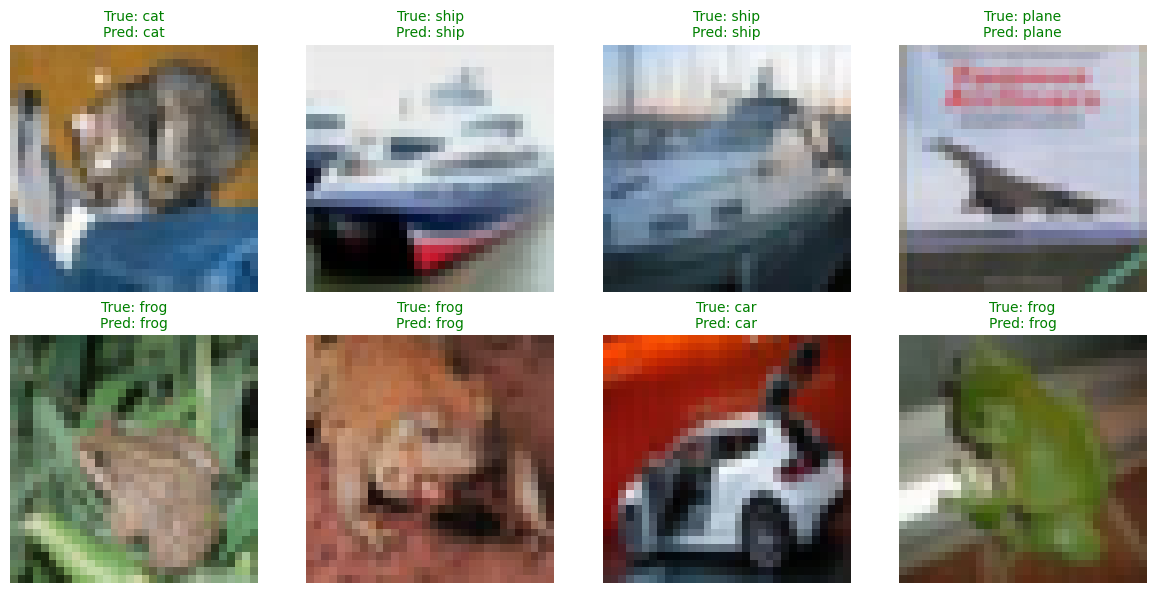

In [22]:
# Visualize predictions

# Get one batch from testloader
images, labels = next(iter(testloader))
images_gpu = images.to(device)
outputs = model(images_gpu)
_, predicted = outputs.max(1)

# Show 8 images with predictions
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
mean = torch.tensor(MEAN).view(3,1,1)
std = torch.tensor(STD).view(3,1,1)

for i, ax in enumerate(axes.flat):
    img = images[i] * std + mean  # denormalize
    img = img.permute(1, 2, 0).numpy().clip(0, 1)
    true_label = CLASSES[labels[i]]
    pred_label = CLASSES[predicted[i].item()]
    color = 'green' if labels[i] == predicted[i] else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Training loop for MobileNetV2 (Model B)



In [23]:
# Model B - MobileNetV2 (target model for transferability experiment)
if 'USE_CHECKPOINTS' in globals() and USE_CHECKPOINTS:
    print("Skipping training — Model B loaded from checkpoint")
else:
    model_b = models.mobilenet_v2(weights=None, num_classes=NUM_CLASSES)
    # MobileNetV2 expects 224×224 by default but works on 32×32 — just fix the classifier input
    model_b.classifier[1] = nn.Linear(model_b.last_channel, 10)
    model_b = model_b.to(device)

    MB_EPOCHS = 30   # 30 epochs is enough to get ~88% clean acc
    mb_criterion = nn.CrossEntropyLoss()
    mb_optimizer = torch.optim.SGD(model_b.parameters(), lr=0.05,
                                    momentum=0.9, weight_decay=5e-4)
    mb_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(mb_optimizer, T_max=MB_EPOCHS)



    print("Training Model B (MobileNetV2)...")
    for epoch in range(MB_EPOCHS):
        t0 = time.time()
        model_b.train()
        correct, total, running_loss = 0, 0, 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            mb_optimizer.zero_grad()
            out  = model_b(images)
            loss = mb_criterion(out, labels)
            loss.backward()
            mb_optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct      += out.argmax(1).eq(labels).sum().item()
            total        += labels.size(0)

        mb_scheduler.step()

        train_loss_b = running_loss / total
        train_acc_b = 100 * correct / total
        elapsed_b = time.time() - t0

        model_b.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                test_correct += model_b(images).argmax(1).eq(labels).sum().item()
                test_total   += labels.size(0)

        test_acc_b = 100 * test_correct / test_total



        print(f"Epoch {epoch+1:2d}/30 | "
            f"Train Loss: {train_loss_b:.4f} | "
            f"Train Acc: {train_acc_b:.2f}% | "
            f"Test Acc: {test_acc_b:.2f}% | "
            f"Time: {elapsed_b:.1f}s")

    ckpt_path = '/content/drive/MyDrive/cifar_project/checkpoints/model_b_mobilenetv2.pt'
    torch.save({'model_state_dict': model_b.state_dict(), 'test_acc': test_acc_b}, ckpt_path)
    print(f"Model B saved. Clean acc: {test_acc_b:.2f}%")

Skipping training — Model B loaded from checkpoint


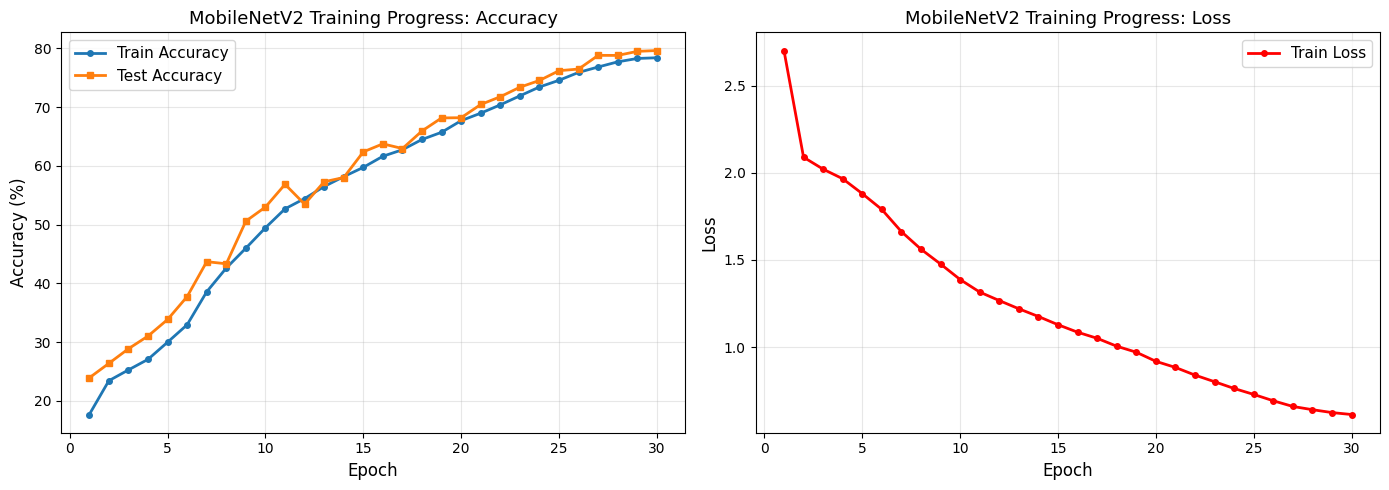

Final train acc: 78.40%
Final test acc:  79.63%
Gap: -1.23%


In [24]:
# Display training curves for Model B (MobileNetV2)
epochs_range_b = list(range(1, 31))

train_accs_b = [17.69, 23.44, 25.28, 27.08, 30.00, 32.97, 38.58, 42.62,
                46.00, 49.47, 52.69, 54.44, 56.49, 58.17, 59.75, 61.64,
                62.75, 64.50, 65.72, 67.70, 68.97, 70.39, 71.92, 73.43,
                74.57, 75.91, 76.83, 77.71, 78.28, 78.40]

test_accs_b = [23.93, 26.39, 28.88, 31.04, 33.86, 37.76, 43.70, 43.34,
               50.60, 53.00, 56.86, 53.49, 57.30, 58.02, 62.39, 63.75,
               62.95, 65.95, 68.16, 68.20, 70.45, 71.77, 73.39, 74.54,
               76.20, 76.48, 78.81, 78.80, 79.49, 79.63]

train_losses_b = [2.7010, 2.0891, 2.0206, 1.9656, 1.8802, 1.7894, 1.6622, 1.5615,
                  1.4764, 1.3876, 1.3156, 1.2669, 1.2197, 1.1755, 1.1283, 1.0855,
                  1.0504, 1.0051, 0.9706, 0.9184, 0.8833, 0.8393, 0.8013, 0.7626,
                  0.7285, 0.6921, 0.6595, 0.6410, 0.6244, 0.6133]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range_b, train_accs_b, 'o-', label='Train Accuracy', linewidth=2, markersize=4)
ax1.plot(epochs_range_b, test_accs_b, 's-', label='Test Accuracy', linewidth=2, markersize=4)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('MobileNetV2 Training Progress: Accuracy', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

ax2.plot(epochs_range_b, train_losses_b, 'o-', color='red', label='Train Loss', linewidth=2, markersize=4)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('MobileNetV2 Training Progress: Loss', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cifar_project/results/training_curves_mobilenet.png', dpi=200)
plt.show()

print(f"Final train acc: {train_accs_b[-1]:.2f}%")
print(f"Final test acc:  {test_accs_b[-1]:.2f}%")
print(f"Gap: {train_accs_b[-1] - test_accs_b[-1]:.2f}%")

#FGSM attacks

In [25]:
# FGSM from scratch
def fgsm_attack(model, images, labels, epsilon):
    """
    Generates adversarial examples using Fast Gradient Sign Method.

    Args:
        model: trained neural network
        images: batch of original images (already on device)
        labels: true labels
        epsilon: perturbation magnitude

    Returns:
        adversarial images
    """
    # Enable gradient tracking for input images
    images = images.clone().detach().requires_grad_(True)

    # Forward pass
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    # Backward pass: compute gradient w.r.t. input images
    model.zero_grad()
    loss.backward()

    # Create adversarial example: x + ε * sign(gradient)
    adv_images = images + epsilon * images.grad.sign()

    # Clip to valid image range [0, 1]
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()

In [26]:
model.eval()

fgsm_accuracies = []

for eps, label in zip(EPSILONS, EPSILON_LABELS):
    correct = 0
    total = 0

    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        if eps == 0:
            adv_images = images  # clean accuracy
        else:
            adv_images = fgsm_attack(model, images, labels, eps)

        with torch.no_grad():
            outputs = model(adv_images)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    fgsm_accuracies.append(acc)
    print(f"FGSM ε={label:>8s}  →  Accuracy: {acc:.2f}%")

print(f"\nFGSM evaluation complete")

FGSM ε=       0  →  Accuracy: 93.81%
FGSM ε=   2/255  →  Accuracy: 47.83%
FGSM ε=   4/255  →  Accuracy: 44.98%
FGSM ε=   8/255  →  Accuracy: 40.35%
FGSM ε=  16/255  →  Accuracy: 33.93%
FGSM ε=  32/255  →  Accuracy: 26.54%

FGSM evaluation complete


In [27]:
# Verify FGSM against torchattacks

# Take one batch for comparison
images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

# Our FGSM
eps = 8/255
our_adv = fgsm_attack(model, images, labels, eps)

# Library FGSM
lib_attack = torchattacks.FGSM(model, eps=eps)
lib_adv = lib_attack(images, labels)

# Compare accuracies
model.eval()
with torch.no_grad():
    our_preds = model(our_adv).argmax(1)
    lib_preds = model(lib_adv).argmax(1)

our_acc = 100 * (our_preds == labels).float().mean().item()
lib_acc = 100 * (lib_preds == labels).float().mean().item()

# Compare pixel-level difference
max_diff = (our_adv - lib_adv).abs().max().item()
mean_diff = (our_adv - lib_adv).abs().mean().item()

print(f"Our FGSM accuracy:        {our_acc:.2f}%")
print(f"torchattacks accuracy:    {lib_acc:.2f}%")
print(f"Max pixel difference:     {max_diff:.6f}")
print(f"Mean pixel difference:    {mean_diff:.6f}")

if max_diff < 0.001 and abs(our_acc - lib_acc) < 1.0:
    print("\nFGSM implementation verified correctly!")
else:
    print("\nResults differ - check implementation")

Our FGSM accuracy:        42.19%
torchattacks accuracy:    42.19%
Max pixel difference:     0.000000
Mean pixel difference:    0.000000

FGSM implementation verified correctly!


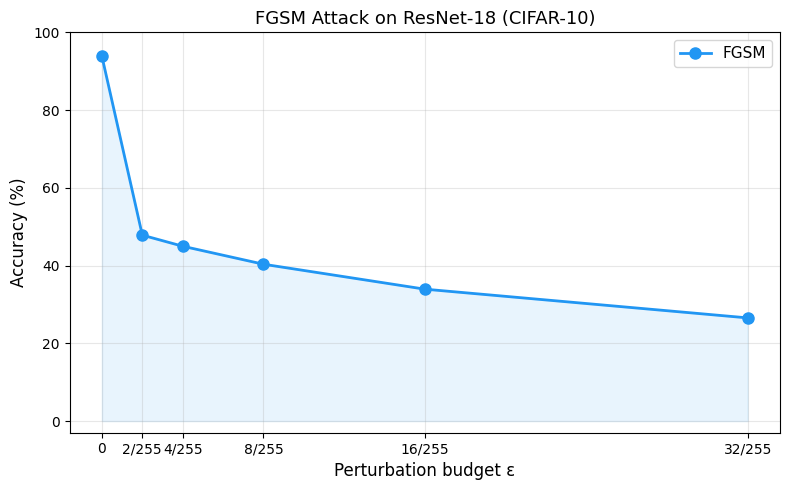

In [28]:
# Plot FGSM accuracy vs epsilon
plt.figure(figsize=(8, 5))
plt.plot(EPSILONS, fgsm_accuracies, 'o-', color='#2196F3', linewidth=2, markersize=8, label='FGSM')
plt.fill_between(EPSILONS, fgsm_accuracies, alpha=0.1, color='#2196F3')
plt.xlabel('Perturbation budget ε', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('FGSM Attack on ResNet-18 (CIFAR-10)', fontsize=13)
plt.xticks(EPSILONS, EPSILON_LABELS)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.ylim(-3, 100)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cifar_project/results/accuracy_vs_epsilon.png', dpi=200)
plt.show()

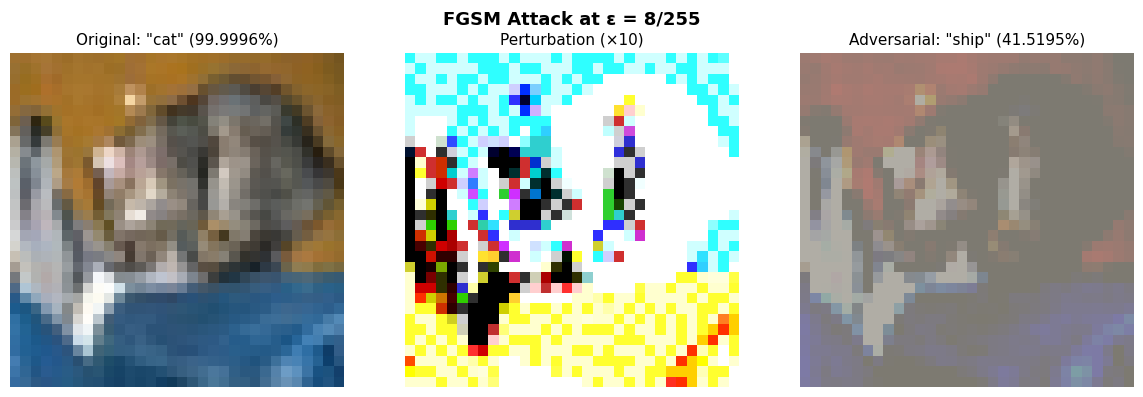

In [29]:
# Visualize adversarial examples
model.eval()
img, lab = testset[0]  # take first test image
x = img.unsqueeze(0).to(device)
y = torch.tensor([lab]).to(device)

adv = fgsm_attack(model, x, y, 8/255)
noise = adv - x

# Predictions
with torch.no_grad():
    clean_pred = model(x).argmax(1).item()
    clean_conf = torch.softmax(model(x), 1).max().item()
    adv_pred = model(adv).argmax(1).item()
    adv_conf = torch.softmax(model(adv), 1).max().item()

# Denormalize for display
mean = torch.tensor(MEAN).view(1,3,1,1).to(device)
std = torch.tensor(STD).view(1,3,1,1).to(device)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
img_show = (x[0].cpu() * std[0].cpu() + mean[0].cpu()).permute(1,2,0).clamp(0,1).numpy()
axes[0].imshow(img_show)
axes[0].set_title(f'Original: "{CLASSES[clean_pred]}" ({clean_conf:.4%})', fontsize=11)
axes[0].axis('off')

# Noise (amplified 10x)
noise_show = (noise[0].cpu() * 10 + 0.5).permute(1,2,0).clamp(0,1).numpy()
axes[1].imshow(noise_show)
axes[1].set_title('Perturbation (×10)', fontsize=11)
axes[1].axis('off')

# Adversarial
adv_show = (adv[0].cpu() * std[0].cpu() + mean[0].cpu()).permute(1,2,0).clamp(0,1).numpy()
axes[2].imshow(adv_show)
axes[2].set_title(f'Adversarial: "{CLASSES[adv_pred]}" ({adv_conf:.4%})', fontsize=11)
axes[2].axis('off')

plt.suptitle(f'FGSM Attack at ε = 8/255', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cifar_project/results/adversarial_examples.png', dpi=200)
plt.show()

#Transferability

In [30]:
# Transferability: attack Model A, evaluate on Model B
model.eval()
model_b.eval()

eps = 8/255
correct_a = 0            # Model A accuracy on its own adversarial examples (white-box)
correct_b = 0            # Model B accuracy on Model A's adversarial examples (black-box)
fooled_a_count = 0       # samples where A was fooled
fooled_both_count = 0    # samples where A AND B were both fooled (same inputs)
total = 0

for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)

    # Generate adversarial examples using Model A
    adv_images = fgsm_attack(model, images, labels, eps)

    with torch.no_grad():
        pred_a = model(adv_images).argmax(1)
        pred_b = model_b(adv_images).argmax(1)

        correct_a_mask = (pred_a == labels)
        correct_b_mask = (pred_b == labels)

        correct_a += correct_a_mask.sum().item()
        correct_b += correct_b_mask.sum().item()

        # Per-sample fool masks
        fooled_a_mask = ~correct_a_mask
        fooled_b_mask = ~correct_b_mask

        # Intersection: A fooled AND B fooled on the SAME sample
        fooled_a_count    += fooled_a_mask.sum().item()
        fooled_both_count += (fooled_a_mask & fooled_b_mask).sum().item()

        total += labels.size(0)

acc_a = 100 * correct_a / total
acc_b = 100 * correct_b / total

# Transferability rate: of attacks that fooled Model A, how many also fooled Model B?
transfer_rate = 100 * fooled_both_count / fooled_a_count if fooled_a_count > 0 else 0

print(f"Model A (ResNet-18) under FGSM ε=8/255:")
print(f"  White-box accuracy: {acc_a:.2f}%")
print(f"  Attack Success Rate: {100-acc_a:.2f}%")
print(f"")
print(f"Model B (MobileNetV2) on Model A's adversarial examples:")
print(f"  Black-box accuracy: {acc_b:.2f}%")
print(f"  Attack Success Rate: {100-acc_b:.2f}%")
print(f"")
print(f"Transferability rate: {transfer_rate:.1f}%")
print(f"(of attacks that fooled ResNet-18, {transfer_rate:.1f}% also fooled MobileNetV2)")

Model A (ResNet-18) under FGSM ε=8/255:
  White-box accuracy: 40.35%
  Attack Success Rate: 59.65%

Model B (MobileNetV2) on Model A's adversarial examples:
  Black-box accuracy: 37.08%
  Attack Success Rate: 62.92%

Transferability rate: 78.3%
(of attacks that fooled ResNet-18, 78.3% also fooled MobileNetV2)


=== Model A (ResNet-18) — Clean Data ===
              precision    recall  f1-score   support

       plane      0.940     0.948     0.944      1000
         car      0.971     0.965     0.968      1000
        bird      0.934     0.909     0.921      1000
         cat      0.867     0.882     0.875      1000
        deer      0.935     0.955     0.945      1000
         dog      0.897     0.893     0.895      1000
        frog      0.962     0.950     0.956      1000
       horse      0.974     0.945     0.959      1000
        ship      0.953     0.974     0.963      1000
       truck      0.950     0.960     0.955      1000

    accuracy                          0.938     10000
   macro avg      0.938     0.938     0.938     10000
weighted avg      0.938     0.938     0.938     10000



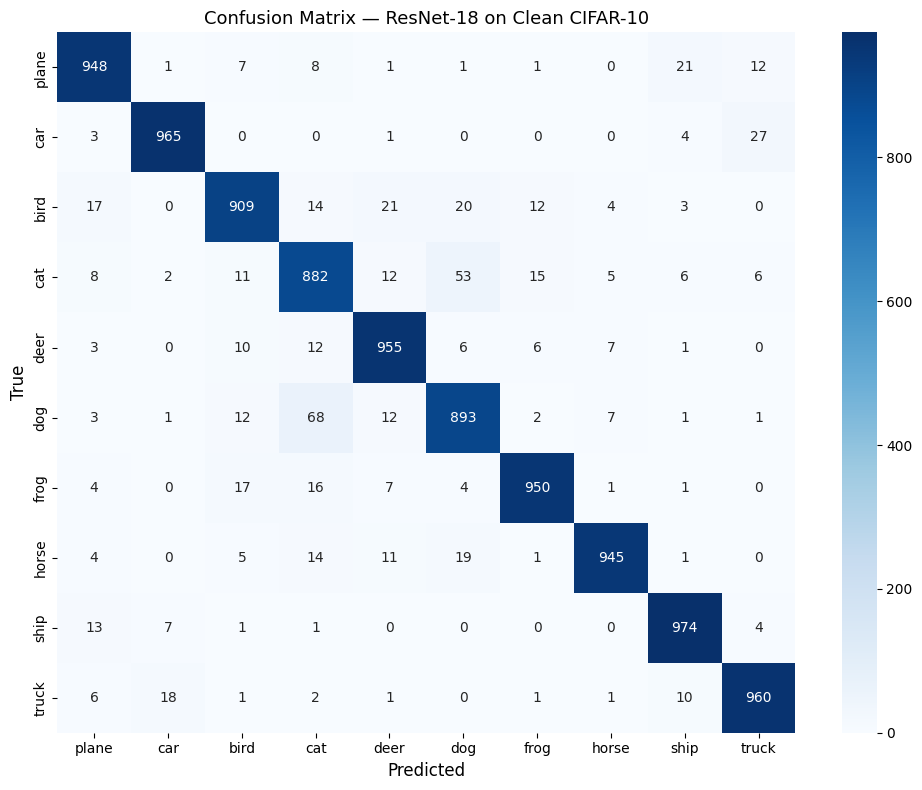

In [31]:
# Per-class accuracy and confusion matrix on clean data
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        preds = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Per-class report
print("=== Model A (ResNet-18) — Clean Data ===")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=3))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix — ResNet-18 on Clean CIFAR-10', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cifar_project/results/confusion_matrix_clean.png', dpi=200)
plt.show()

#FGSM Adversarial Training

In [32]:
# Train a new ResNet-18 on a 50/50 mix of clean and FGSM adversarial examples

# Fresh model for adversarial training
if 'USE_CHECKPOINTS' in globals() and USE_CHECKPOINTS:
    print("Skipping FGSM-AT training — model_at loaded from checkpoint")
else:
    model_at = models.resnet18(weights=None, num_classes=NUM_CLASSES)
    model_at.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model_at.maxpool = nn.Identity()
    model_at = model_at.to(device)

    AT_EPOCHS = 50
    AT_EPSILON = 8/255

    at_optimizer = torch.optim.SGD(model_at.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    at_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(at_optimizer, T_max=AT_EPOCHS)
    at_criterion = nn.CrossEntropyLoss()

    for epoch in range(AT_EPOCHS):
        model_at.train()
        start = time.time()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            batch_size = images.size(0)

            # Generate FGSM adversarial examples against current model
            model_at.eval()  # eval mode for correct batchnorm during attack
            adv_images = fgsm_attack(model_at, images, labels, AT_EPSILON)
            model_at.train()  # back to train mode for weight update

            # 50/50 mix: first half clean, second half adversarial
            half = batch_size // 2
            mixed_images = torch.cat([images[:half], adv_images[half:]], dim=0)
            mixed_labels = torch.cat([labels[:half], labels[half:]], dim=0)

            # Standard training step on the mixed batch
            at_optimizer.zero_grad()
            outputs = model_at(mixed_images)
            loss = at_criterion(outputs, mixed_labels)
            loss.backward()
            at_optimizer.step()

            running_loss += loss.item() * mixed_images.size(0)
            train_correct += (outputs.argmax(1) == mixed_labels).sum().item()
            train_total += mixed_labels.size(0)

        at_scheduler.step()
        train_loss = running_loss / train_total
        train_acc = 100 * train_correct / train_total
        elapsed = time.time() - start

        # Evaluate on clean test data
        model_at.eval()
        clean_correct = 0
        clean_total = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                clean_correct += (model_at(images).argmax(1) == labels).sum().item()
                clean_total += labels.size(0)
        clean_acc = 100 * clean_correct / clean_total

        # Print every 5 epochs to reduce clutter
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"FGSM-AT Epoch {epoch+1:2d}/{AT_EPOCHS} | "
                  f"Loss: {train_loss:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | "
                  f"Clean Test Acc: {clean_acc:.2f}% | "
                  f"Time: {elapsed:.1f}s")

    print("\nFGSM-AT training complete!")

Skipping FGSM-AT training — model_at loaded from checkpoint


In [33]:
# Save FGSM-AT model
if 'USE_CHECKPOINTS' in globals() and USE_CHECKPOINTS:
    print("Skipping save — model_at loaded from checkpoint")
else:
    torch.save({
        'model_state_dict': model_at.state_dict(),
        'clean_accuracy': clean_acc,
        'epsilon': AT_EPSILON,
        'epochs': AT_EPOCHS,
    }, '/content/drive/MyDrive/cifar_project/checkpoints/fgsm_at_resnet18.pt')

    print(f"FGSM-AT model saved. Clean acc: {clean_acc:.2f}%")

Skipping save — model_at loaded from checkpoint


#Evaluate FGSM-AT model under FGSM attack

In [34]:
# Evaluate FGSM-AT model under FGSM attack
model_at.eval()

print("FGSM-AT model evaluation:")
print(f"{'Epsilon':>10s}  {'Clean/Robust Acc':>18s}  {'Attack Success Rate':>20s}")
print("-" * 55)

for eps, label in zip(EPSILONS, EPSILON_LABELS):
    correct = 0
    total = 0

    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        if eps == 0:
            adv_images = images
        else:
            adv_images = fgsm_attack(model_at, images, labels, eps)

        with torch.no_grad():
            correct += (model_at(adv_images).argmax(1) == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    asr = 100 - acc
    print(f"ε={label:>8s}  →  Accuracy: {acc:6.2f}%     ASR: {asr:6.2f}%")

FGSM-AT model evaluation:
   Epsilon    Clean/Robust Acc   Attack Success Rate
-------------------------------------------------------
ε=       0  →  Accuracy:  92.83%     ASR:   7.17%
ε=   2/255  →  Accuracy:  84.40%     ASR:  15.60%
ε=   4/255  →  Accuracy:  82.91%     ASR:  17.09%
ε=   8/255  →  Accuracy:  79.94%     ASR:  20.06%
ε=  16/255  →  Accuracy:  73.47%     ASR:  26.53%
ε=  32/255  →  Accuracy:  61.19%     ASR:  38.81%


#Evaluation Matrix, Transferability, Extended Metrics

Standard (ResNet-18) | Clean: 100%|██████████| 79/79 [00:03<00:00, 26.12it/s]


  => 93.81%



Standard (ResNet-18) | FGSM ε=0.0314: 100%|██████████| 79/79 [00:10<00:00,  7.25it/s]


  => 40.35%



FGSM-AT (ResNet-18) | Clean: 100%|██████████| 79/79 [00:02<00:00, 26.41it/s]


  => 92.83%



FGSM-AT (ResNet-18) | FGSM ε=0.0314: 100%|██████████| 79/79 [00:10<00:00,  7.24it/s]


  => 79.94%

2x2 White-box Evaluation Matrix
Model                            Clean      FGSM ε=0.0314
------------------------------------------------------------
Standard (ResNet-18)            93.81%             40.35%
FGSM-AT (ResNet-18)             92.83%             79.94%
------------------------------------------------------------


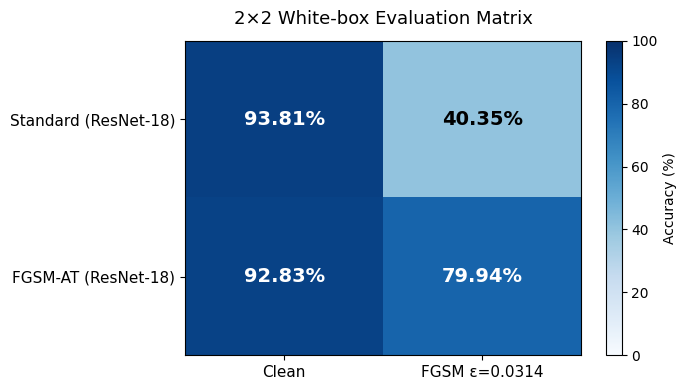

In [35]:
# 2x2 White-box Evaluation Matrix
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

models_dict = {
    'Standard (ResNet-18)': model,
    'FGSM-AT (ResNet-18)':  model_at,
}

eps = 8/255
attack_label = f'FGSM ε={eps:.4f}'   # Label stays in sync with eps
results_matrix = {}

for model_name, cur_model in models_dict.items():
    cur_model.eval()
    results_matrix[model_name] = {}

    for attack_name in ['Clean', attack_label]:
        correct, total = 0, 0

        for images, labels in tqdm(testloader, desc=f"{model_name} | {attack_name}"):
            images, labels = images.to(device), labels.to(device)

            if attack_name == 'Clean':
                test_images = images
            else:
                # White-box: attack is generated against the same model we evaluate
                test_images = fgsm_attack(cur_model, images, labels, eps)

            with torch.no_grad():
                preds = cur_model(test_images).argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)

        acc = 100 * correct / total
        results_matrix[model_name][attack_name] = acc
        print(f"  => {acc:.2f}%\n")

# Print the matrix (text)
print("=" * 60)
print("2x2 White-box Evaluation Matrix")
print("=" * 60)
print(f"{'Model':<25s} {'Clean':>12s} {attack_label:>18s}")
print("-" * 60)
for model_name, accs in results_matrix.items():
    clean = accs['Clean']
    fgsm  = accs[attack_label]
    print(f"{model_name:<25s} {clean:>11.2f}% {fgsm:>17.2f}%")
print("-" * 60)

# --- Visualize the 2x2 matrix as a heatmap ---
row_labels = list(results_matrix.keys())
col_labels = ['Clean', attack_label]
data = np.array([
    [results_matrix[m]['Clean'], results_matrix[m][attack_label]]
    for m in row_labels
])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(data, cmap='Blues', vmin=0, vmax=100, aspect='auto')

ax.set_xticks(range(len(col_labels)))
ax.set_yticks(range(len(row_labels)))
ax.set_xticklabels(col_labels, fontsize=11)
ax.set_yticklabels(row_labels, fontsize=11)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        color = 'white' if val > 55 else 'black'
        ax.text(j, i, f'{val:.2f}%', ha='center', va='center',
                color=color, fontsize=14, fontweight='bold')

ax.set_title('2×2 White-box Evaluation Matrix', fontsize=13, pad=12)
plt.colorbar(im, ax=ax, label='Accuracy (%)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cifar_project/results/eval_matrix_2x2.png', dpi=200)
plt.show()

In [36]:
# Full Transferability Experiment: ResNet-18 -> MobileNetV2
from tqdm import tqdm

model.eval()
model_at.eval()
model_b.eval()

eps = 8/255

# 1) Compute MobileNetV2 clean baseline ONCE (independent of source)
correct_clean_b, total_clean = 0, 0
with torch.no_grad():
    for images, labels in tqdm(testloader, desc="MobileNetV2 clean baseline"):
        images, labels = images.to(device), labels.to(device)
        preds = model_b(images).argmax(1)
        correct_clean_b += (preds == labels).sum().item()
        total_clean     += labels.size(0)
acc_clean_b = 100 * correct_clean_b / total_clean

print("=" * 70)
print(f"Transferability: FGSM (ε={eps:.4f}) from ResNet-18 -> MobileNetV2")
print(f"MobileNetV2 clean baseline: {acc_clean_b:.2f}%")
print("=" * 70)

# 2) Iterate over source models
sources = [
    ('Standard ResNet-18', model),
    ('FGSM-AT ResNet-18',  model_at),
]

for source_name, source_model in sources:
    correct_source = 0      # white-box accuracy on source
    correct_target = 0      # black-box accuracy on target (adv inputs)
    transfer_hits  = 0      # correct on clean -> wrong on adv (honest transfer-ASR)
    base_correct_b = 0      # how many target samples were correct on clean
    total = 0

    for images, labels in tqdm(testloader, desc=source_name):
        images, labels = images.to(device), labels.to(device)

        # Build adversarial examples on the source model
        adv_images = fgsm_attack(source_model, images, labels, eps)

        with torch.no_grad():
            src_preds       = source_model(adv_images).argmax(1)
            tgt_preds_adv   = model_b(adv_images).argmax(1)
            tgt_preds_clean = model_b(images).argmax(1)

            correct_source += (src_preds == labels).sum().item()
            correct_target += (tgt_preds_adv == labels).sum().item()

            # Honest transfer-ASR: only count samples the target
            # got right on clean but wrong on adv
            mask_correct_clean = (tgt_preds_clean == labels)
            base_correct_b += mask_correct_clean.sum().item()
            transfer_hits  += (mask_correct_clean & (tgt_preds_adv != labels)).sum().item()

            total += labels.size(0)

    acc_source     = 100 * correct_source / total
    acc_target_adv = 100 * correct_target / total
    drop_b         = acc_clean_b - acc_target_adv
    transfer_asr   = 100 * transfer_hits / max(base_correct_b, 1)

    print(f"\nSource: {source_name}")
    print(f"  White-box accuracy (source):      {acc_source:.2f}%   (ASR: {100-acc_source:.2f}%)")
    print(f"  Black-box accuracy (MobileNetV2): {acc_target_adv:.2f}%   (ASR-naive: {100-acc_target_adv:.2f}%)")
    print(f"  MobileNetV2 accuracy drop:        {drop_b:.2f} pp")
    print(f"  Transfer-ASR (honest):            {transfer_asr:.2f}%   "
          f"(of {base_correct_b}/{total} originally correct)")

MobileNetV2 clean baseline: 100%|██████████| 79/79 [00:02<00:00, 28.01it/s]


Transferability: FGSM (ε=0.0314) from ResNet-18 -> MobileNetV2
MobileNetV2 clean baseline: 79.63%


Standard ResNet-18: 100%|██████████| 79/79 [00:11<00:00,  6.64it/s]



Source: Standard ResNet-18
  White-box accuracy (source):      40.35%   (ASR: 59.65%)
  Black-box accuracy (MobileNetV2): 37.08%   (ASR-naive: 62.92%)
  MobileNetV2 accuracy drop:        42.55 pp
  Transfer-ASR (honest):            59.20%   (of 7963/10000 originally correct)


FGSM-AT ResNet-18: 100%|██████████| 79/79 [00:12<00:00,  6.44it/s]


Source: FGSM-AT ResNet-18
  White-box accuracy (source):      79.94%   (ASR: 20.06%)
  Black-box accuracy (MobileNetV2): 36.62%   (ASR-naive: 63.38%)
  MobileNetV2 accuracy drop:        43.01 pp
  Transfer-ASR (honest):            59.64%   (of 7963/10000 originally correct)



############################################################
  EXTENDED METRICS FOR ALL MODEL-ATTACK COMBINATIONS
############################################################

  Standard ResNet-18 — Clean
              precision    recall  f1-score   support

       plane      0.940     0.948     0.944      1000
         car      0.971     0.965     0.968      1000
        bird      0.934     0.909     0.921      1000
         cat      0.867     0.882     0.875      1000
        deer      0.935     0.955     0.945      1000
         dog      0.897     0.893     0.895      1000
        frog      0.962     0.950     0.956      1000
       horse      0.974     0.945     0.959      1000
        ship      0.953     0.974     0.963      1000
       truck      0.950     0.960     0.955      1000

    accuracy                          0.938     10000
   macro avg      0.938     0.938     0.938     10000
weighted avg      0.938     0.938     0.938     10000

  Accuracy: 93.81%
  Macro-F1: 0.93

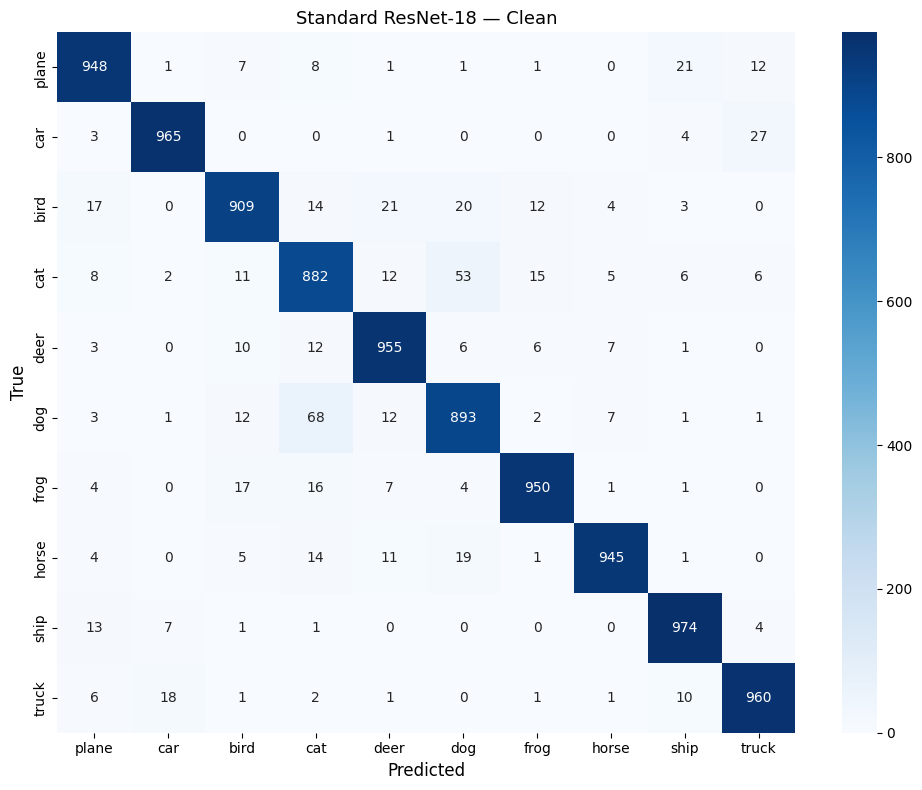


  Standard ResNet-18 — FGSM eps=8-255
              precision    recall  f1-score   support

       plane      0.304     0.701     0.424      1000
         car      0.882     0.270     0.413      1000
        bird      0.397     0.500     0.442      1000
         cat      0.362     0.222     0.275      1000
        deer      0.511     0.385     0.439      1000
         dog      0.438     0.225     0.297      1000
        frog      0.607     0.421     0.497      1000
       horse      0.850     0.289     0.431      1000
        ship      0.274     0.806     0.409      1000
       truck      0.812     0.216     0.341      1000

    accuracy                          0.404     10000
   macro avg      0.544     0.404     0.397     10000
weighted avg      0.544     0.404     0.397     10000

  Accuracy: 40.35%
  Macro-F1: 0.397


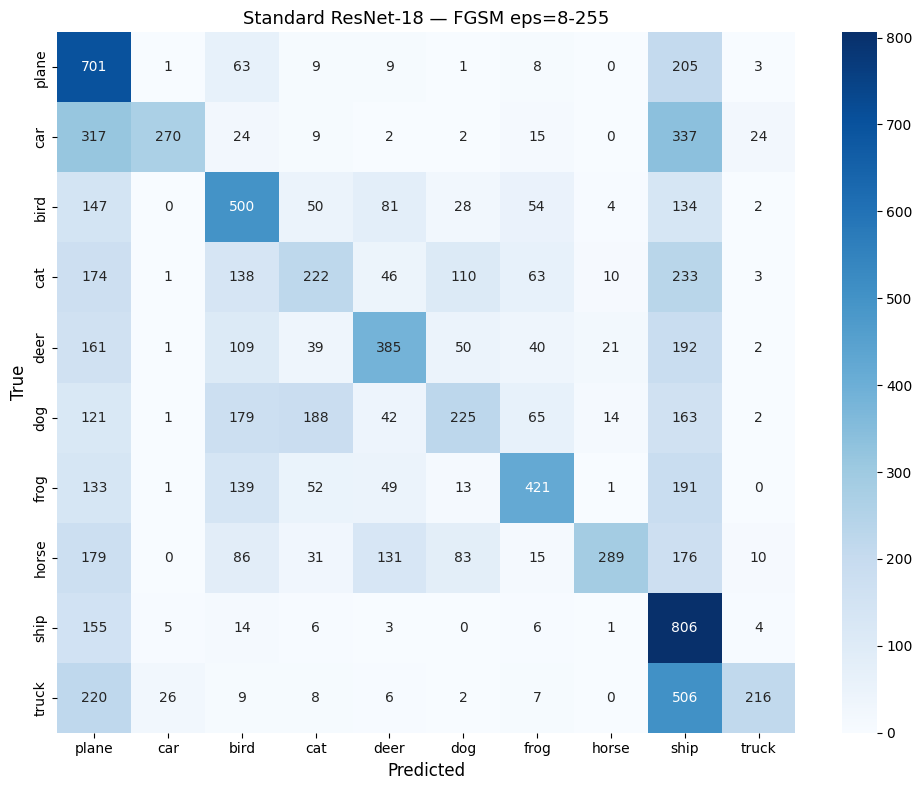


  FGSM-AT ResNet-18 — Clean
              precision    recall  f1-score   support

       plane      0.931     0.934     0.933      1000
         car      0.970     0.965     0.967      1000
        bird      0.910     0.915     0.913      1000
         cat      0.844     0.832     0.838      1000
        deer      0.923     0.948     0.935      1000
         dog      0.877     0.869     0.873      1000
        frog      0.956     0.948     0.952      1000
       horse      0.964     0.953     0.958      1000
        ship      0.951     0.962     0.956      1000
       truck      0.957     0.957     0.957      1000

    accuracy                          0.928     10000
   macro avg      0.928     0.928     0.928     10000
weighted avg      0.928     0.928     0.928     10000

  Accuracy: 92.83%
  Macro-F1: 0.928


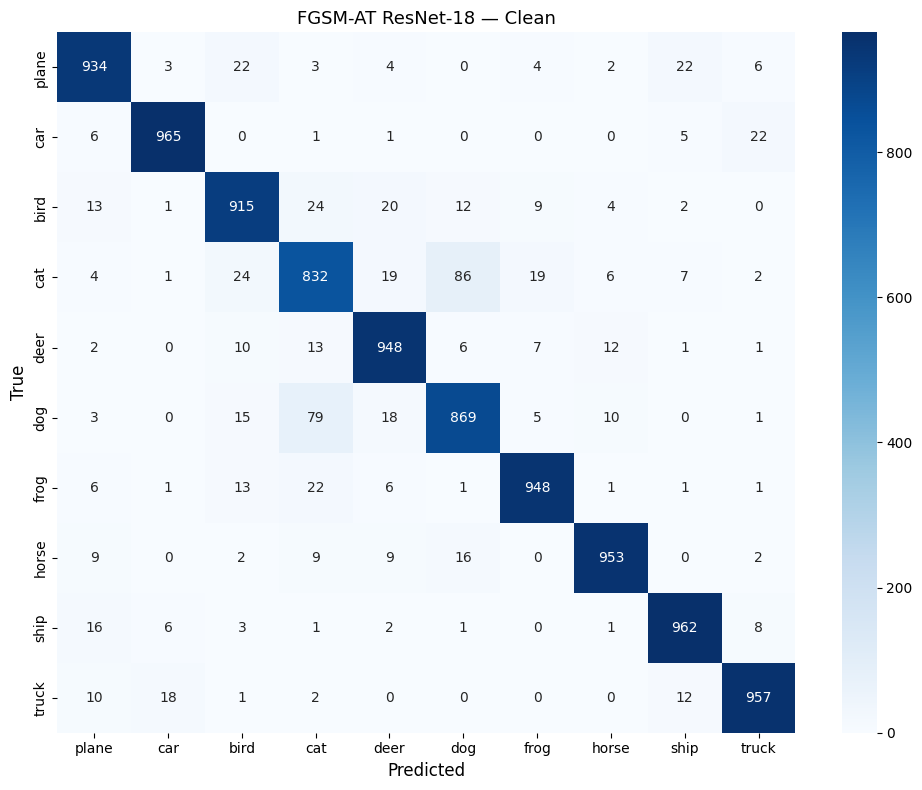


  FGSM-AT ResNet-18 — FGSM eps=8-255
              precision    recall  f1-score   support

       plane      0.860     0.828     0.844      1000
         car      0.912     0.886     0.899      1000
        bird      0.737     0.723     0.730      1000
         cat      0.620     0.614     0.617      1000
        deer      0.762     0.767     0.764      1000
         dog      0.720     0.708     0.714      1000
        frog      0.813     0.846     0.829      1000
       horse      0.859     0.855     0.857      1000
        ship      0.842     0.889     0.865      1000
       truck      0.868     0.878     0.873      1000

    accuracy                          0.799     10000
   macro avg      0.799     0.799     0.799     10000
weighted avg      0.799     0.799     0.799     10000

  Accuracy: 79.94%
  Macro-F1: 0.799


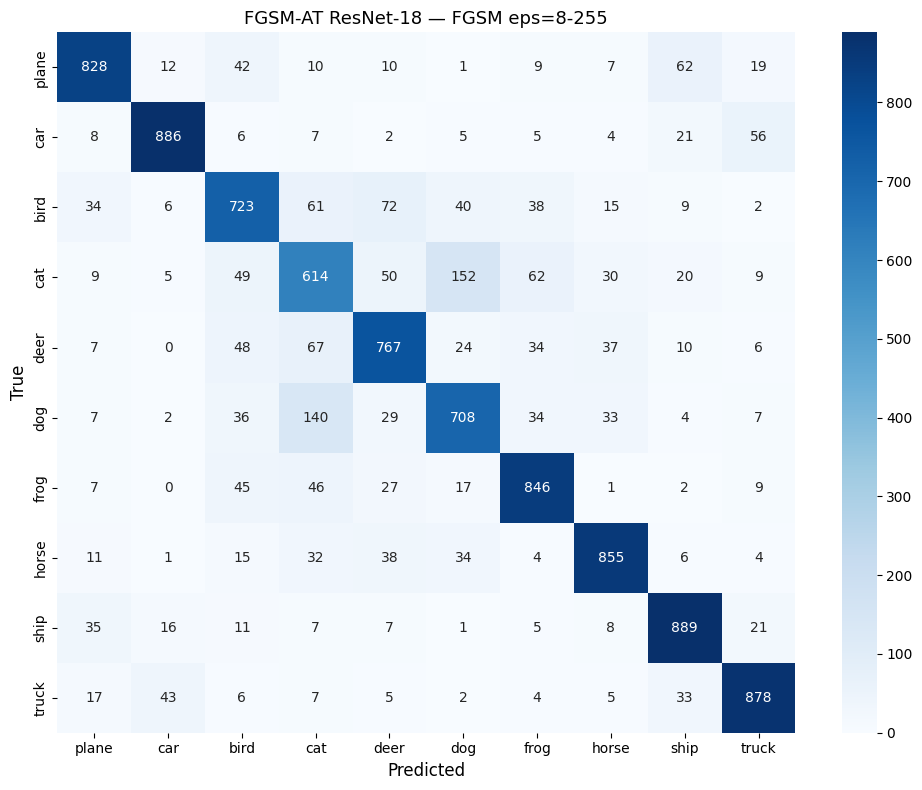

(np.float64(79.94), 0.7991518806502678)

In [37]:
# Extended Metrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

def evaluate_with_metrics(model_eval, testloader, attack_fn=None, epsilon=0, title=""):
    """Compute full metrics for a model, optionally under attack."""
    model_eval.eval()
    all_preds = []
    all_labels = []

    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        if attack_fn and epsilon > 0:
            images = attack_fn(model_eval, images, labels, epsilon)

        with torch.no_grad():
            preds = model_eval(images).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # Classification report
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    report = classification_report(all_labels, all_preds, target_names=CLASSES, digits=3)
    print(report)

    # Macro-F1
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    accuracy = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  Macro-F1: {macro_f1:.3f}")

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/cifar_project/results/cm_{title.replace(" ", "_").lower()}.png', dpi=200)
    plt.show()

    return accuracy, macro_f1

# Run all 4 combinations
print("\n" + "#"*60)
print("  EXTENDED METRICS FOR ALL MODEL-ATTACK COMBINATIONS")
print("#"*60)

# 1. Standard model, clean data
evaluate_with_metrics(model, testloader,
    title="Standard ResNet-18 — Clean")

# 2. Standard model, under FGSM
evaluate_with_metrics(model, testloader, fgsm_attack, 8/255,
    title="Standard ResNet-18 — FGSM eps=8-255")

# 3. FGSM-AT model, clean data
evaluate_with_metrics(model_at, testloader,
    title="FGSM-AT ResNet-18 — Clean")

# 4. FGSM-AT model, under FGSM
evaluate_with_metrics(model_at, testloader, fgsm_attack, 8/255,
    title="FGSM-AT ResNet-18 — FGSM eps=8-255")

#Final Summary Table

In [38]:
# Display final Summary Table
eps = 8/255
attack_label = f'FGSM ε={eps:.4f}'

print("\n" + "=" * 75)
print("  FINAL RESULTS SUMMARY")
print("=" * 75)

print(f"\n--- 2x2 Evaluation Matrix ---")
print(f"{'Model':<25s} {'Clean Acc':>12s} {'FGSM Acc':>12s} {'Acc Drop':>12s} {'Robust Gain':>12s}")
print("-" * 75)
for model_name in results_matrix:
    clean = results_matrix[model_name]['Clean']
    fgsm  = results_matrix[model_name][attack_label]
    drop  = results_matrix['Standard (ResNet-18)']['Clean'] - clean
    gain  = fgsm - results_matrix['Standard (ResNet-18)'][attack_label]
    print(f"{model_name:<25s} {clean:>11.2f}% {fgsm:>11.2f}% {drop:>+11.2f}% {gain:>+11.2f}%")

print(f"\n--- Key Findings ---")
baseline_clean = results_matrix['Standard (ResNet-18)']['Clean']
baseline_fgsm  = results_matrix['Standard (ResNet-18)'][attack_label]
at_clean       = results_matrix['FGSM-AT (ResNet-18)']['Clean']
at_fgsm        = results_matrix['FGSM-AT (ResNet-18)'][attack_label]

clean_change = at_clean - baseline_clean   # positive = grew, negative = dropped

print(f"1. FGSM at ε=8/255 drops baseline accuracy from {baseline_clean:.1f}% to {baseline_fgsm:.1f}% (ASR: {100-baseline_fgsm:.1f}%)")
print(f"2. FGSM-AT improves robust accuracy from {baseline_fgsm:.1f}% to {at_fgsm:.1f}% (+{at_fgsm-baseline_fgsm:.1f}%)")
print(f"3. Clean accuracy change from {baseline_clean:.1f}% to {at_clean:.1f}% ({clean_change:+.1f}%)")
print(f"4. This is consistent with the robustness-accuracy trade-off (Tsipras et al., ICLR 2019)")


  FINAL RESULTS SUMMARY

--- 2x2 Evaluation Matrix ---
Model                        Clean Acc     FGSM Acc     Acc Drop  Robust Gain
---------------------------------------------------------------------------
Standard (ResNet-18)            93.81%       40.35%       +0.00%       +0.00%
FGSM-AT (ResNet-18)             92.83%       79.94%       +0.98%      +39.59%

--- Key Findings ---
1. FGSM at ε=8/255 drops baseline accuracy from 93.8% to 40.4% (ASR: 59.6%)
2. FGSM-AT improves robust accuracy from 40.4% to 79.9% (+39.6%)
3. Clean accuracy change from 93.8% to 92.8% (-1.0%)
4. This is consistent with the robustness-accuracy trade-off (Tsipras et al., ICLR 2019)
